In [1]:
# import and config

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

# PATH
DATA_DIR   = "dataset/"    
OUTPUT_DIR = "eda_output/"
OUTPUT_DIR_1 = "eda_output_revised/"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR_1, exist_ok=True)

BRAND_COLOR = {
    "Richeese": "#378ADD",
    "Richoco":  "#D4537E",
    "Nextar":   "#1D9E75",
}
CAT_COLOR = {
    "Wafer":          "#378ADD",
    "Kue/Pie":        "#1D9E75",
    "Minuman":        "#D4537E",
    "Mi Instan":      "#BA7517",
    "Extruded Snack": "#534AB7",
    "Biskuit":        "#888780",
}

# PLOT STYLE 
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.grid":        True,
    "grid.alpha":       0.3,
    "grid.linestyle":   "--",
    "font.size":        11,
})

print("✅ Config selesai")
print(f"   Working dir : {os.getcwd()}")
print(f"   Data dir    : {DATA_DIR} — exists: {os.path.exists(DATA_DIR)}")
print(f"   Output dir  : {OUTPUT_DIR} — exists: {os.path.exists(OUTPUT_DIR)}")
print(f"   Output dir  : {OUTPUT_DIR_1} — exists: {os.path.exists(OUTPUT_DIR_1)}")

✅ Config selesai
   Working dir : d:\Intern - Capstone Project\eda
   Data dir    : dataset/ — exists: True
   Output dir  : eda_output/ — exists: True
   Output dir  : eda_output_revised/ — exists: True


In [2]:
# load data

df1 = pd.read_csv(DATA_DIR + "transaction_1.csv", index_col=0)
df2 = pd.read_csv(DATA_DIR + "transaction_2.csv", index_col=0)

# convert DateTime sebelum concat
df1["DateTime"] = pd.to_datetime(df1["DateTime"], errors="coerce")
df2["DateTime"] = pd.to_datetime(df2["DateTime"], errors="coerce")

print(f"df1 : {df1['DateTime'].min().date()} → {df1['DateTime'].max().date()} | {len(df1):,} rows")
print(f"df2 : {df2['DateTime'].min().date()} → {df2['DateTime'].max().date()} | {len(df2):,} rows")

df1 : 2025-05-01 → 2025-10-30 | 250,001 rows
df2 : 2025-05-01 → 2025-10-30 | 250,001 rows


In [3]:
"""Ditemukan 1 TransactionID (`T068690`) yang ada di kedua file dengan isi berbeda, 
kemungkinan ID generator reset di salah satu sistem. 
Karena TransactionID hanya dipakai untuk `nunique()` dan tidak ada analisis row-level, 
maka tidak perlu di-handle khusus (langsung concat)."""

df = pd.concat([df1, df2], ignore_index=True)

# derive kolom waktu 
df["Date"]  = df["DateTime"].dt.date
df["Week"]  = df["DateTime"].dt.to_period("W").apply(lambda r: r.start_time.date())
df["Month"] = df["DateTime"].dt.to_period("M")

print(f"Total rows setelah concat : {len(df):,}")
print(f"Unique TransactionID      : {df['TransactionID'].nunique():,}")
print(f"Avg SKU per transaksi     : {len(df) / df['TransactionID'].nunique():.2f}")


Total rows setelah concat : 500,002
Unique TransactionID      : 179,987
Avg SKU per transaksi     : 2.78


In [4]:
# basic info & quality check

print("=" * 60)
print("BASIC INFO")
print("=" * 60)
print(f"Shape         : {df.shape}")
print(f"Date range    : {df['DateTime'].min().date()} → {df['DateTime'].max().date()}")
print(f"Branches      : {sorted(df['Branch'].unique())}")
print(f"Brands        : {sorted(df['Brand'].unique())}")
print(f"Categories    : {sorted(df['SKU_Category'].unique())}")
print(f"Promo types   : {sorted(df['Promo_Category'].unique())}")
print(f"Unique SKU    : {df['SKU_ID'].nunique()}")

print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "✅ Tidak ada missing values")

print("\n" + "=" * 60)
print("DUPLICATE CHECK")
print("=" * 60)
full_dup = df.duplicated().sum()
print(f"Full row duplicate : {full_dup} {'✅' if full_dup == 0 else '⚠️'}")

# Cek TransactionID duplikat (expected: 1 transaksi bisa multi SKU)
dup_txn = df[df["TransactionID"].duplicated(keep=False)]
print(f"\nRows dengan TransactionID duplikat  : {len(dup_txn):,}")
print(f"Unique TransactionID yang duplikat  : {dup_txn['TransactionID'].nunique():,}")
print("Interpretasi: normal, karena 1 TransactionID bisa punya banyak baris (multi-SKU per transaksi)")
print("\nContoh 10 baris (diurutkan per TransactionID):")
display(dup_txn.sort_values("TransactionID").head(10))

BASIC INFO
Shape         : (500002, 18)
Date range    : 2025-05-01 → 2025-10-30
Branches      : ['Bandung', 'Jakarta', 'Semarang', 'Surabaya']
Brands        : ['Nextar', 'Richeese', 'Richoco']
Categories    : ['Biskuit', 'Extruded Snack', 'Kue/Pie', 'Mi Instan', 'Minuman', 'Wafer']
Promo types   : ['No Promo', 'Promo Bundling', 'Promo Normal', 'Promo Seasonal High']
Unique SKU    : 20

MISSING VALUES
✅ Tidak ada missing values

DUPLICATE CHECK
Full row duplicate : 0 ✅

Rows dengan TransactionID duplikat  : 477,350
Unique TransactionID yang duplikat  : 157,335
Interpretasi: normal, karena 1 TransactionID bisa punya banyak baris (multi-SKU per transaksi)

Contoh 10 baris (diurutkan per TransactionID):


,TransactionID,DateTime,Date_Key,Branch,Customer_ID,SKU_ID,SKU,Brand,SKU_Category,Qty,NormalPrice,DiscountedPrice,DiscountPercentage,Total_Price,Promo_Category,Date,Week,Month
365994,T000001,2025-08-08 16:08:43,20250808,Jakarta,C31780,S020,Richeese Mi Instan Goreng,Richeese,Mi Instan,3,3500.0,3200.0,0.10,9600.0,Promo Normal,2025-08-08,2025-08-04,2025-08
365995,T000001,2025-08-08 16:08:43,20250808,Jakarta,C31780,S005,Nextar Brownies Pie 40g,Nextar,Kue/Pie,5,8000.0,7600.0,0.05,38000.0,Promo Normal,2025-08-08,2025-08-04,2025-08
213268,T000002,2025-05-30 13:32:48,20250530,Jakarta,C56637,S008,Richoco Ahh! Extruded 15g,Richoco,Extruded Snack,1,4500.0,4500.0,0.00,4500.0,No Promo,2025-05-30,2025-05-26,2025-05
213267,T000002,2025-05-30 13:32:48,20250530,Jakarta,C56637,S009,Richeese Mi Instan Keju Pedas,Richeese,Mi Instan,5,3500.0,3500.0,0.00,17500.0,No Promo,2025-05-30,2025-05-26,2025-05
213269,T000002,2025-05-30 13:32:48,20250530,Jakarta,C56637,S004,Richoco Wafer Cokelat 10g Renceng,Richoco,Wafer,1,10000.0,10000.0,0.00,10000.0,No Promo,2025-05-30,2025-05-26,2025-05
217500,T000003,2025-05-30 10:32:42,20250530,Surabaya,C56189,S013,Nabati Drinko Richeese 150ml,Richeese,Minuman,3,4000.0,2000.0,0.50,6000.0,Promo Bundling,2025-05-30,2025-05-26,2025-05
217501,T000003,2025-05-30 10:32:42,20250530,Surabaya,C56189,S002,Richoco Wafer Cokelat 50g,Richoco,Wafer,2,5500.0,5500.0,0.00,11000.0,Promo Bundling,2025-05-30,2025-05-26,2025-05
217499,T000003,2025-05-30 10:32:42,20250530,Surabaya,C56189,S001,Richeese Wafer Keju 50g,Richeese,Wafer,3,5500.0,5200.0,0.05,15600.0,Promo Bundling,2025-05-30,2025-05-26,2025-05
225413,T000005,2025-07-01 18:10:10,20250701,Surabaya,C53913,S013,Nabati Drinko Richeese 150ml,Richeese,Minuman,4,4000.0,4000.0,0.00,16000.0,No Promo,2025-07-01,2025-06-30,2025-07
225414,T000005,2025-07-01 18:10:10,20250701,Surabaya,C53913,S008,Richoco Ahh! Extruded 15g,Richoco,Extruded Snack,3,4500.0,4500.0,0.00,13500.0,No Promo,2025-07-01,2025-06-30,2025-07


#### Interpretasi
###### - kolom Week isinya tanggal Senin dari minggu tersebut, fungsinya sebagai ID unik per minggu supaya kita bisa groupby("Week") untuk agregasi mingguan
###### - Raw data (setelah concat) tidak memiliki kolom revenue, adanya kolom total price per raw

In [5]:
# Discount Pattern Analysis
""""
Key findings:
- Semua SKU memiliki `Discount_Day_Ratio = 1.0`
- Artinya setiap hari selama 180 hari, semua transaksi selalu di bawah `NormalPrice`
- `NormalPrice` harus dibaca sebagai list price, bukan harga yang benar-benar dibayar 
- Untuk modeling, kita akan pakai `DiscountedPrice` sebagai harga efektif
"""

# Hitung berapa hari per SKU ada diskon (DiscountedPrice < NormalPrice)
daily_discount = (
    df.groupby(["SKU", "Date_Key"])
      .agg(
          NormalPrice    =("NormalPrice",     "mean"),
          DiscountedPrice=("DiscountedPrice",  "mean")
      )
      .reset_index()
)
daily_discount["HasDiscount"] = daily_discount["DiscountedPrice"] < daily_discount["NormalPrice"]

discount_summary = (
    daily_discount.groupby("SKU")
    .agg(
        Total_Days   =("Date_Key",    "nunique"),
        Discount_Days=("HasDiscount", "sum")
    )
    .reset_index()
)
discount_summary["Discount_Day_Ratio"] = (
    discount_summary["Discount_Days"] / discount_summary["Total_Days"]
).round(2)

display(discount_summary.sort_values("Discount_Day_Ratio", ascending=False))

# Implikasi
always_discounted = (discount_summary["Discount_Day_Ratio"] == 1.0).all()
print(f"\n{'✅' if always_discounted else '⚠️'} Semua SKU selalu kena diskon tiap hari: {always_discounted}")
print("→ NormalPrice = list price; DiscountedPrice = harga efektif yang dipakai untuk modeling")

,SKU,Total_Days,Discount_Days,Discount_Day_Ratio
0,Nabati Biskuit Rasa Cokelat,180,180,1.0
1,Nabati Biskuit Rasa Kelapa,180,180,1.0
2,Nabati Drinko Richeese 150ml,180,180,1.0
3,Nabati Drinko Richoco 150ml,180,180,1.0
4,Nextar Brownies Pie 40g,180,180,1.0
5,Nextar Choco Delight 40g,180,180,1.0
6,Nextar Nastar Pie 30g,180,180,1.0
7,Nextar Pineapple Pie 30g,180,180,1.0
8,Richeese Mi Instan Goreng,180,180,1.0
9,Richeese Mi Instan Keju Pedas,180,180,1.0



✅ Semua SKU selalu kena diskon tiap hari: True
→ NormalPrice = list price; DiscountedPrice = harga efektif yang dipakai untuk modeling


In [6]:
# sku summary

sku_summary = (
    df.groupby(["SKU_ID", "SKU", "Brand", "SKU_Category"])
    .agg(
        total_qty        = ("Qty",               "sum"),
        total_revenue    = ("Total_Price",        "sum"),
        transactions     = ("TransactionID",      "nunique"),
        normal_price     = ("NormalPrice",        "median"),
        avg_discount_pct = ("DiscountPercentage", "mean"),
        max_discount_pct = ("DiscountPercentage", "max"),
    )
    .reset_index()
    .sort_values("SKU_ID")
)
sku_summary["avg_discount_pct"] = (sku_summary["avg_discount_pct"] * 100).round(2)
sku_summary["max_discount_pct"] = (sku_summary["max_discount_pct"] * 100).round(2)

display(sku_summary[[
    "SKU_ID", "SKU", "Brand", "SKU_Category",
    "total_qty", "total_revenue", "normal_price",
    "avg_discount_pct", "max_discount_pct"
]])

,SKU_ID,SKU,Brand,SKU_Category,total_qty,total_revenue,normal_price,avg_discount_pct,max_discount_pct
0,S001,Richeese Wafer Keju 50g,Richeese,Wafer,143659,788933500.0,5500.0,5.23,30.0
1,S002,Richoco Wafer Cokelat 50g,Richoco,Wafer,67266,369837400.0,6100.0,5.29,30.0
2,S003,Richeese Wafer Keju 10g Renceng,Richeese,Wafer,67306,637933000.0,10000.0,5.23,30.0
3,S004,Richoco Wafer Cokelat 10g Renceng,Richoco,Wafer,67626,640569500.0,10000.0,5.27,30.0
4,S005,Nextar Brownies Pie 40g,Nextar,Kue/Pie,67487,491110100.0,8000.0,5.20,30.0
5,S006,Nextar Nastar Pie 30g,Nextar,Kue/Pie,66937,487094600.0,8000.0,5.21,30.0
6,S007,Richeese Siip Keju 20g,Richeese,Extruded Snack,68164,192972600.0,3000.0,5.28,30.0
7,S008,Richoco Ahh! Extruded 15g,Richoco,Extruded Snack,66627,284062800.0,4500.0,5.24,30.0
8,S009,Richeese Mi Instan Keju Pedas,Richeese,Mi Instan,67003,222095700.0,3500.0,5.29,30.0
9,S010,Richeese Mi Instan Ramen Keju,Richeese,Mi Instan,67062,254326200.0,4000.0,5.23,30.0


##### Interpretasi
###### - Di sini, qty dan revenue masih digabung antar category promo, belum dilihat per category promo

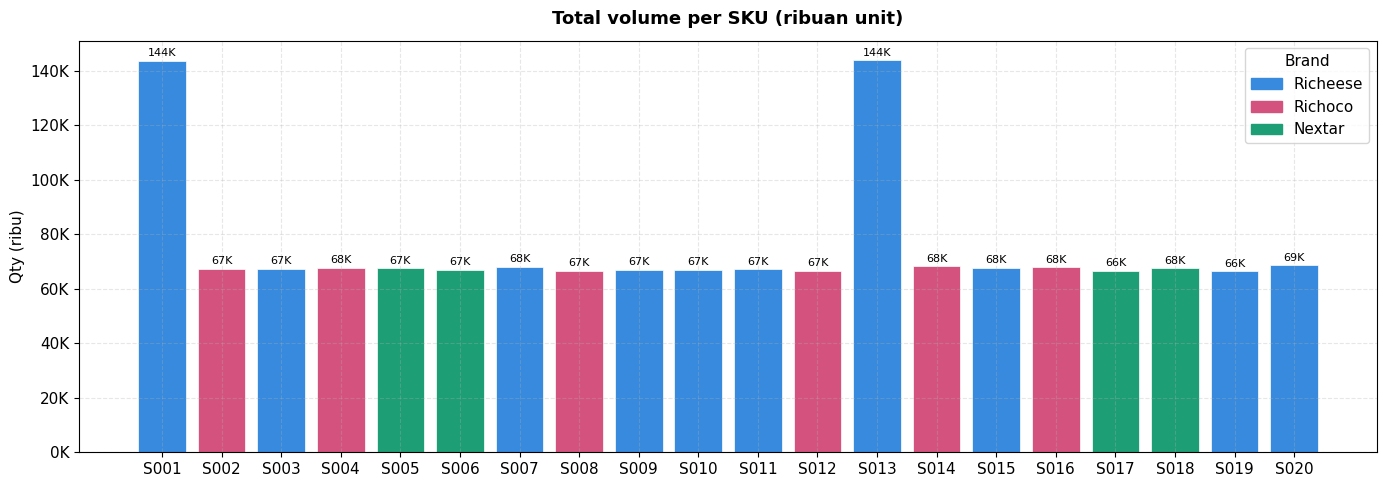

✓ Saved: 01_volume_per_sku.png


In [7]:
# total volume per SKU 

fig, ax = plt.subplots(figsize=(14, 5))
colors = [BRAND_COLOR[b] for b in sku_summary["Brand"]]
bars = ax.bar(sku_summary["SKU_ID"], sku_summary["total_qty"] / 1000,
              color=colors, edgecolor="white", linewidth=0.5)

ax.set_title("Total volume per SKU (ribuan unit)", fontsize=13, fontweight="bold", pad=12)
ax.set_ylabel("Qty (ribu)")
ax.set_xlabel("")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}K"))

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 1,
            f"{h:.0f}K", ha="center", va="bottom", fontsize=8)

legend_patches = [plt.Rectangle((0, 0), 1, 1, color=c) for c in BRAND_COLOR.values()]
ax.legend(legend_patches, BRAND_COLOR.keys(), title="Brand", loc="upper right")

plt.tight_layout()
plt.savefig(OUTPUT_DIR_1 + "01_volume_per_sku.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved: 01_volume_per_sku.png")

##### Interpretasi
###### - Dari ketiga brand (Richeese, Richoco, dan Nextar), yang paling banyak qty terjual adalah Richeese


In [8]:
# cek distribusi data

print(df["Promo_Category"].value_counts())
print(df["DiscountPercentage"].describe())

Promo_Category
No Promo               224116
Promo Normal           148405
Promo Bundling          78315
Promo Seasonal High     49166
Name: count, dtype: int64
count    500002.000000
mean          0.076623
std           0.126325
min           0.000000
25%           0.000000
50%           0.050000
75%           0.100000
max           0.500000
Name: DiscountPercentage, dtype: float64


##### Interpretasi
###### - 25% data  → DiscountPercentage = 0.00  (no promo, bayar full)
###### - 50% data  → DiscountPercentage = 0.05
###### - 75% data  → DiscountPercentage = 0.10

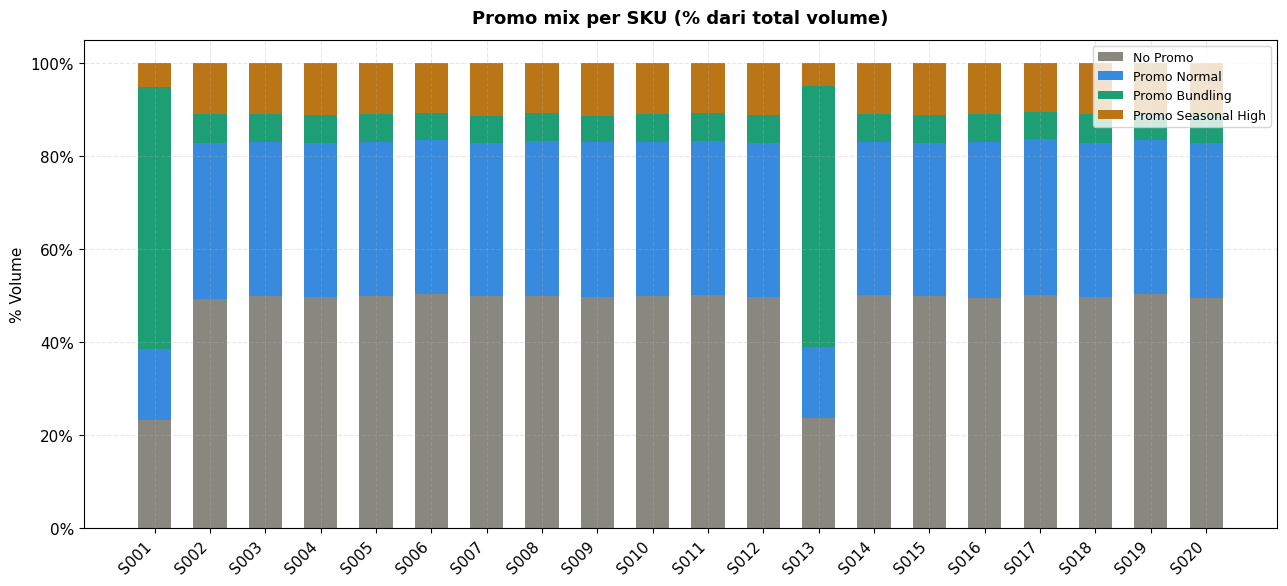

✓ Saved: 04_promo_mix.png


In [9]:
# promo mix per SKU 
promo_mix = (
    df.groupby(["SKU_ID", "Promo_Category"])["Qty"]
    .sum()
    .reset_index()
)
promo_pivot = promo_mix.pivot(index="SKU_ID", columns="Promo_Category", values="Qty").fillna(0)
promo_pivot = promo_pivot.div(promo_pivot.sum(axis=1), axis=0) * 100  # normalize to %

promo_colors = {
    "No Promo":           "#888780",
    "Promo Normal":       "#378ADD",
    "Promo Bundling":     "#1D9E75",
    "Promo Seasonal High":"#BA7517",
}

fig, ax = plt.subplots(figsize=(13, 6))
bottom = np.zeros(len(promo_pivot))
for promo_type in ["No Promo", "Promo Normal", "Promo Bundling", "Promo Seasonal High"]:
    if promo_type in promo_pivot.columns:
        vals = promo_pivot[promo_type].values
        ax.bar(promo_pivot.index, vals, bottom=bottom,
               label=promo_type, color=promo_colors.get(promo_type, "#ccc"), width=0.6)
        bottom += vals

ax.set_title("Promo mix per SKU (% dari total volume)", fontsize=13, fontweight="bold", pad=12)
ax.set_ylabel("% Volume")
ax.set_xlabel("")
ax.legend(loc="upper right", fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "04_promo_mix.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved: 04_promo_mix.png")

##### Interpretasi
###### - Persentase kategori "No Promo" mendominasi di hampir semua SKU dengan nilai sekitar 50%


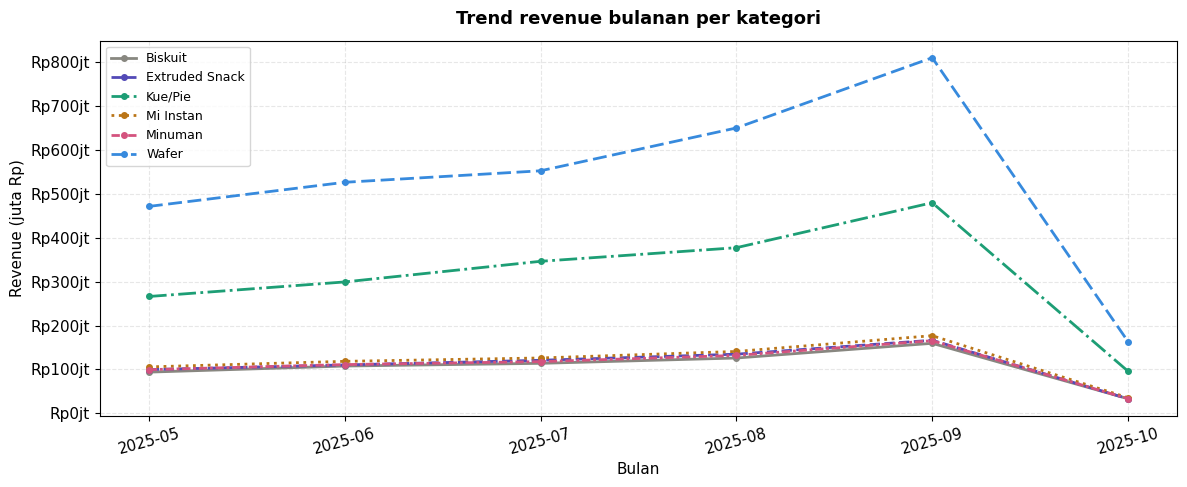

✓ Saved: 02_monthly_revenue_trend.png


In [10]:
# monthly revenue trend per category 
monthly_cat = (
    df.groupby(["Month", "SKU_Category"])["Total_Price"]
    .sum()
    .reset_index()
)
monthly_cat["Month_str"] = monthly_cat["Month"].astype(str)
pivot_rev = monthly_cat.pivot(index="Month_str", columns="SKU_Category", values="Total_Price").fillna(0)

fig, ax = plt.subplots(figsize=(12, 5))
linestyles = ["-", "--", "-.", ":", (0, (3, 1, 1, 1)), (0, (5, 2))]
for i, cat in enumerate(pivot_rev.columns):
    ax.plot(pivot_rev.index, pivot_rev[cat] / 1e6,
            marker="o", markersize=4,
            color=CAT_COLOR.get(cat, "#999"),
            linestyle=linestyles[i % len(linestyles)],
            label=cat, linewidth=2)

ax.set_title("Trend revenue bulanan per kategori", fontsize=13, fontweight="bold", pad=12)
ax.set_ylabel("Revenue (juta Rp)")
ax.set_xlabel("Bulan")
ax.legend(loc="upper left", fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"Rp{x:.0f}jt"))
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(OUTPUT_DIR_1 + "02_monthly_revenue_trend.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved: 02_monthly_revenue_trend.png")


In [11]:
# kandidat cannibalization 
print("\n" + "=" * 60)
print("Kandidat pasangan cannibalization")
print("=" * 60)

same_cat = df.groupby(["SKU_Category", "SKU_ID", "SKU", "Brand"]).agg(
    total_qty   = ("Qty", "sum"),
    normal_price= ("NormalPrice", "median"),
).reset_index()

print("\nSKU dalam kategori yang sama (potensi substitusi):")
for cat, grp in same_cat.groupby("SKU_Category"):
    if len(grp) > 1:
        print(f"\n  [{cat}]")
        for _, row in grp.iterrows():
            print(f"    {row['SKU_ID']} | {row['Brand']:10s} | Rp{row['normal_price']:,.0f} | {row['total_qty']:,} qty — {row['SKU']}")


Kandidat pasangan cannibalization

SKU dalam kategori yang sama (potensi substitusi):

  [Biskuit]
    S011 | Richeese   | Rp5,000 | 67,118 qty — Nabati Biskuit Rasa Kelapa
    S012 | Richoco    | Rp5,000 | 66,518 qty — Nabati Biskuit Rasa Cokelat

  [Extruded Snack]
    S007 | Richeese   | Rp3,000 | 68,164 qty — Richeese Siip Keju 20g
    S008 | Richoco    | Rp4,500 | 66,627 qty — Richoco Ahh! Extruded 15g
    S019 | Richeese   | Rp3,000 | 66,425 qty — Richeese Siip Jagung Bakar 20g

  [Kue/Pie]
    S005 | Nextar     | Rp8,000 | 67,487 qty — Nextar Brownies Pie 40g
    S006 | Nextar     | Rp8,000 | 66,937 qty — Nextar Nastar Pie 30g
    S017 | Nextar     | Rp7,000 | 66,487 qty — Nextar Choco Delight 40g
    S018 | Nextar     | Rp7,000 | 67,508 qty — Nextar Pineapple Pie 30g

  [Mi Instan]
    S009 | Richeese   | Rp3,500 | 67,003 qty — Richeese Mi Instan Keju Pedas
    S010 | Richeese   | Rp4,000 | 67,062 qty — Richeese Mi Instan Ramen Keju
    S020 | Richeese   | Rp3,500 | 68,607 qty

##### Interpretasi
###### - Potensi cannibalization terjadi tidak hanya dalam satu pasang saja, ini memungkinkan kita untuk melihat produk tidak hanya dalam satu pasang saja. 
###### - Misalnya, set diskon untuk A, maka kita bisa melihat implikasinya untuk B, C, dan D.
###### - Antara B, C, dan D, kita bisa juga melihat potensi selain cannibalization, misalnya complement.


In [12]:
# summary

print("\n" + "=" * 60)
print("Ringkasan temuan EDA")
print("=" * 60)

flags = [
    ("ANOMALI",  "S001 & S013 volume 2x SKU lain (~143K) karena dominasi Promo Bundling"),
    ("HIGH",     "Wafer: 6 SKU dalam kategori sama, S001 vs S015 (harga identik Rp5.500) rawan intra-category cannibalization"),
    ("HIGH",     "Mi Instan: S009 & S020 harga sama Rp3.500, jika salah satu dipromo, very likely saling makan"),
    ("MEDIUM",   "Oktober data truncated (hanya ~30 hari), perlu diexclude atau diweight di modeling"),
    ("MEDIUM",   "Semua SKU trend naik steady Mei-Sep, seasonality effect perlu dikontrol di elasticity model"),
]

for severity, msg in flags:
    print(f"  {severity}: {msg}")

print("\n✅ EDA selesai")
print("   Next step → Phase 2: Cross-price elasticity & cannibalization matrix")



Ringkasan temuan EDA
  ANOMALI: S001 & S013 volume 2x SKU lain (~143K) karena dominasi Promo Bundling
  HIGH: Wafer: 6 SKU dalam kategori sama, S001 vs S015 (harga identik Rp5.500) rawan intra-category cannibalization
  HIGH: Mi Instan: S009 & S020 harga sama Rp3.500, jika salah satu dipromo, very likely saling makan
  MEDIUM: Oktober data truncated (hanya ~30 hari), perlu diexclude atau diweight di modeling
  MEDIUM: Semua SKU trend naik steady Mei-Sep, seasonality effect perlu dikontrol di elasticity model

✅ EDA selesai
   Next step → Phase 2: Cross-price elasticity & cannibalization matrix


      Date SKU_ID                          SKU SKU_Category  normal_price  normal_qty
2025-05-01   S001      Richeese Wafer Keju 50g        Wafer        5500.0         162
2025-05-01   S015 Richeese Wafer Pink Lava 50g        Wafer        5500.0         161
2025-05-02   S001      Richeese Wafer Keju 50g        Wafer        5500.0         200
2025-05-02   S015 Richeese Wafer Pink Lava 50g        Wafer        5500.0         155
2025-05-03   S001      Richeese Wafer Keju 50g        Wafer        5500.0         199
2025-05-03   S015 Richeese Wafer Pink Lava 50g        Wafer        5500.0         118
2025-05-04   S001      Richeese Wafer Keju 50g        Wafer        5500.0         156
2025-05-04   S015 Richeese Wafer Pink Lava 50g        Wafer        5500.0         163
2025-05-05   S001      Richeese Wafer Keju 50g        Wafer        5500.0         154
2025-05-05   S015 Richeese Wafer Pink Lava 50g        Wafer        5500.0         186
2025-05-06   S001      Richeese Wafer Keju 50g        

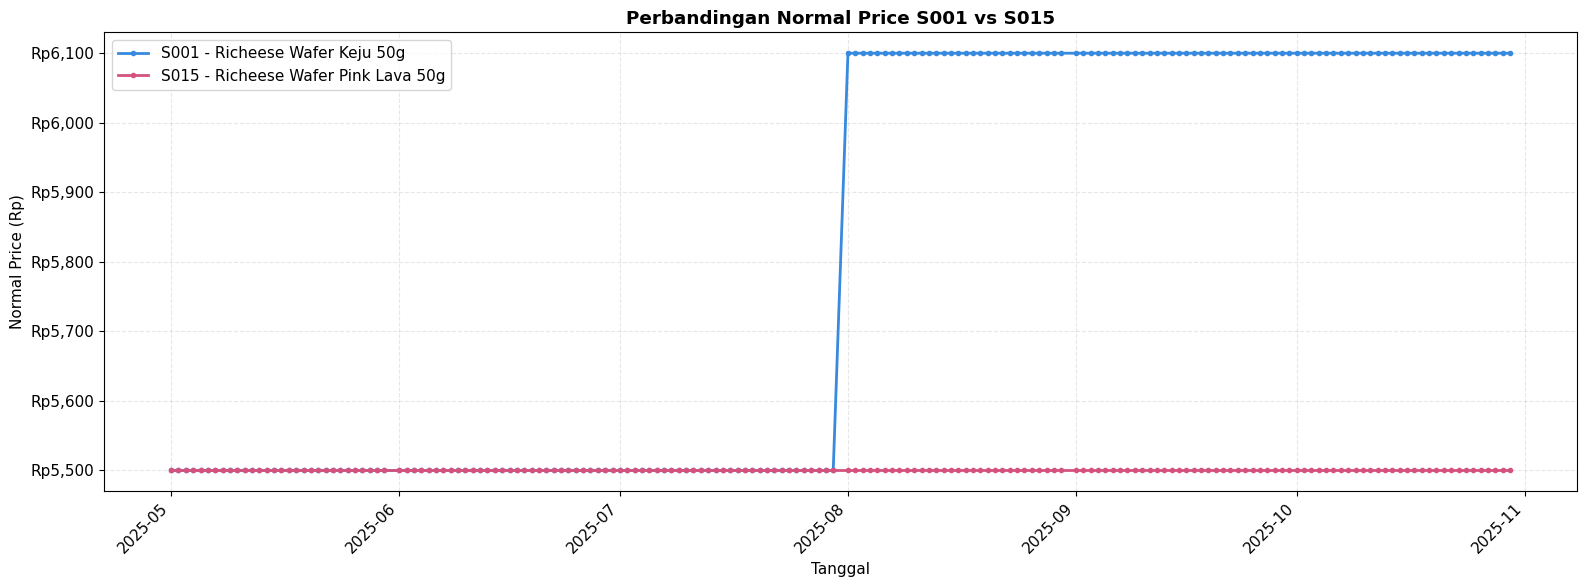

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

csv_path = "eda_output/sku_daily_price_qty_by_promo.csv"

sku_df = pd.read_csv(csv_path)

selected_skus = ["S001", "S015"]
date_col = "Date"

price_comparison = sku_df[sku_df["SKU_ID"].isin(selected_skus)].copy()
price_comparison[date_col] = pd.to_datetime(price_comparison[date_col])

# Hanya tampilkan normal price, tanpa normal_list_price
normal_price_table = price_comparison[
    [
        date_col,
        "SKU_ID",
        "SKU",
        "SKU_Category",
        "normal_price",
        "normal_qty",
    ]
].sort_values([date_col, "SKU_ID"])

# Tampilkan seluruh baris tanpa truncated
print(normal_price_table.to_string(index=False))

# Plot perbandingan normal price
fig, ax = plt.subplots(figsize=(16, 6))

sku_colors = {
    "S001": "#378ADD",
    "S015": "#D4537E",
}

for sku_id in selected_skus:
    sku_data = normal_price_table[
        normal_price_table["SKU_ID"] == sku_id
    ].sort_values(date_col)

    sku_name = sku_data["SKU"].iloc[0]

    ax.plot(
        sku_data[date_col],
        sku_data["normal_price"],
        label=f"{sku_id} - {sku_name}",
        color=sku_colors[sku_id],
        marker="o",
        markersize=3,
        linewidth=2,
    )

ax.set_title("Perbandingan Normal Price S001 vs S015", fontweight="bold")
ax.set_xlabel("Tanggal")
ax.set_ylabel("Normal Price (Rp)")
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"Rp{x:,.0f}")
)
ax.legend()
ax.grid(alpha=0.3, linestyle="--")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

      Date SKU_ID                           SKU SKU_Category  normal_price  normal_qty
2025-05-01   S009 Richeese Mi Instan Keju Pedas    Mi Instan        3500.0         157
2025-05-01   S020     Richeese Mi Instan Goreng    Mi Instan        3500.0         202
2025-05-02   S009 Richeese Mi Instan Keju Pedas    Mi Instan        3500.0         143
2025-05-02   S020     Richeese Mi Instan Goreng    Mi Instan        3500.0         146
2025-05-03   S009 Richeese Mi Instan Keju Pedas    Mi Instan        3500.0         254
2025-05-03   S020     Richeese Mi Instan Goreng    Mi Instan        3500.0         210
2025-05-04   S009 Richeese Mi Instan Keju Pedas    Mi Instan        3500.0         137
2025-05-04   S020     Richeese Mi Instan Goreng    Mi Instan        3500.0         166
2025-05-05   S009 Richeese Mi Instan Keju Pedas    Mi Instan        3500.0         258
2025-05-05   S020     Richeese Mi Instan Goreng    Mi Instan        3500.0         188
2025-05-06   S009 Richeese Mi Instan Keju P

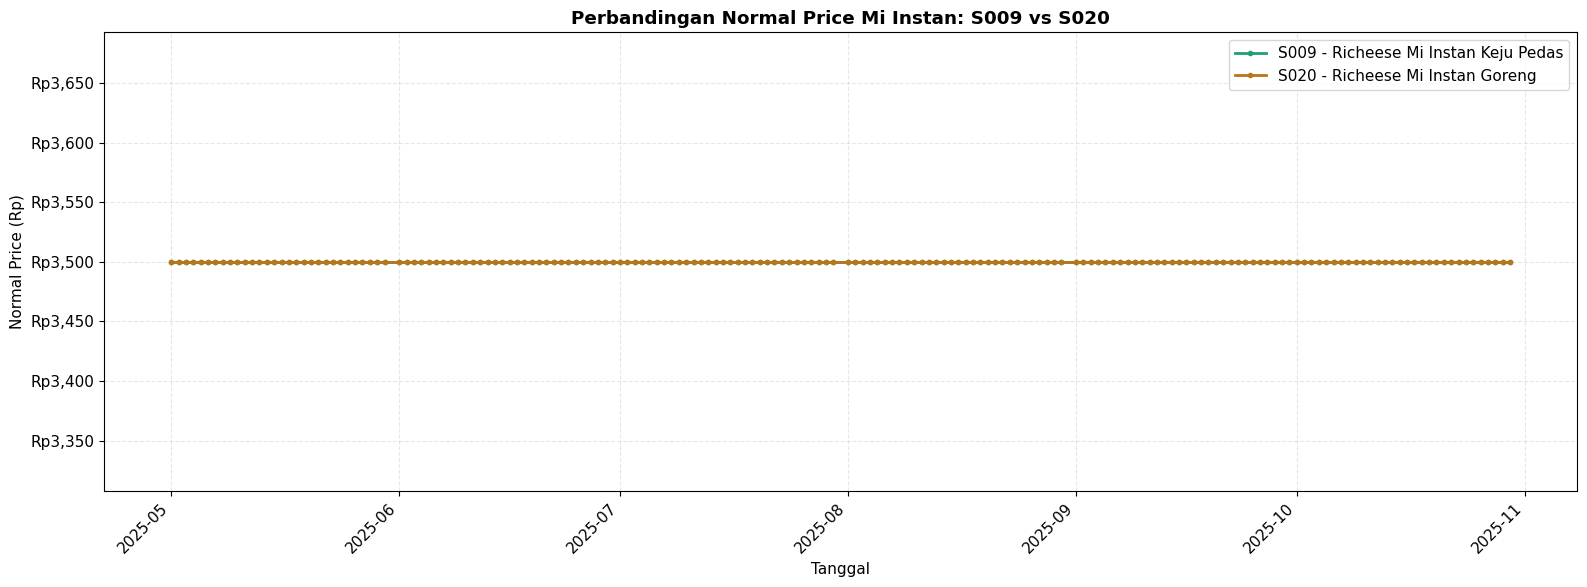

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

csv_path = "eda_output/sku_daily_price_qty_by_promo.csv"

sku_df = pd.read_csv(csv_path)

selected_skus = ["S009", "S020"]
date_col = "Date"

price_comparison = sku_df[sku_df["SKU_ID"].isin(selected_skus)].copy()
price_comparison[date_col] = pd.to_datetime(price_comparison[date_col])

normal_price_table = price_comparison[
    [
        date_col,
        "SKU_ID",
        "SKU",
        "SKU_Category",
        "normal_price",
        "normal_qty",
    ]
].sort_values([date_col, "SKU_ID"])

# Tampilkan semua baris tanpa truncated
print(normal_price_table.to_string(index=False))

# Plot perbandingan normal price
fig, ax = plt.subplots(figsize=(16, 6))

sku_colors = {
    "S009": "#1D9E75",
    "S020": "#BA7517",
}

for sku_id in selected_skus:
    sku_data = normal_price_table[
        normal_price_table["SKU_ID"] == sku_id
    ].sort_values(date_col)

    sku_name = sku_data["SKU"].iloc[0]

    ax.plot(
        sku_data[date_col],
        sku_data["normal_price"],
        label=f"{sku_id} - {sku_name}",
        color=sku_colors[sku_id],
        marker="o",
        markersize=3,
        linewidth=2,
    )

ax.set_title("Perbandingan Normal Price Mi Instan: S009 vs S020", fontweight="bold")
ax.set_xlabel("Tanggal")
ax.set_ylabel("Normal Price (Rp)")
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"Rp{x:,.0f}")
)
ax.legend()
ax.grid(alpha=0.3, linestyle="--")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [15]:
import pandas as pd

# Pastikan DateTime sudah bertipe datetime
df["DateTime"] = pd.to_datetime(df["DateTime"], errors="coerce")
df["Date"] = df["DateTime"].dt.normalize()
df["Month"] = df["DateTime"].dt.to_period("M")

# Hitung jumlah tanggal unik yang tersedia per bulan
days_per_month = (
    df.groupby("Month")
    .agg(
        first_date=("Date", "min"),
        last_date=("Date", "max"),
        available_days=("Date", "nunique"),
        transactions=("TransactionID", "nunique"),
        rows=("TransactionID", "size"),
    )
    .reset_index()
)

# Jumlah hari kalender yang seharusnya ada pada setiap bulan
days_per_month["calendar_days"] = days_per_month["Month"].dt.days_in_month
days_per_month["missing_days"] = (
    days_per_month["calendar_days"] - days_per_month["available_days"]
)
days_per_month["coverage_pct"] = (
    days_per_month["available_days"] / days_per_month["calendar_days"] * 100
).round(2)

days_per_month["Month"] = days_per_month["Month"].astype(str)
days_per_month["first_date"] = days_per_month["first_date"].dt.date
days_per_month["last_date"] = days_per_month["last_date"].dt.date

print(days_per_month.to_string(index=False))

  Month first_date  last_date  available_days  transactions   rows  calendar_days  missing_days  coverage_pct
2025-05 2025-05-01 2025-05-30              30         27074  75206             31             1         96.77
2025-06 2025-06-01 2025-06-30              30         30262  84419             30             0        100.00
2025-07 2025-07-01 2025-07-30              30         32163  89326             31             1         96.77
2025-08 2025-08-01 2025-08-30              30         36087 100238             31             1         96.77
2025-09 2025-09-01 2025-09-30              30         45287 125571             30             0        100.00
2025-10 2025-10-01 2025-10-30              30          9114  25242             31             1         96.77


In [16]:
# perbandingan September vs Oktober
sep_oct = df[df["Month"].astype(str).isin(["2025-09", "2025-10"])]

comparison = (
    sep_oct.groupby("Month")
    .agg(
        total_transactions = ("TransactionID", "nunique"),
        total_rows         = ("TransactionID", "size"),
        total_qty          = ("Qty", "sum"),
        total_revenue      = ("Total_Price", "sum"),
        avg_disc_pct       = ("DiscountPercentage", "mean"),
        unique_skus        = ("SKU_ID", "nunique"),
        unique_customers   = ("Customer_ID", "nunique"),
    )
    .reset_index()
)

comparison["Month"] = comparison["Month"].astype(str)
comparison["total_revenue_jt"] = (comparison["total_revenue"] / 1e6).round(2)
comparison["avg_disc_pct"] = (comparison["avg_disc_pct"] * 100).round(2)

# hitung per-day metrics (Sep=30 hari, Okt=30 hari)
comparison["tx_per_day"]  = (comparison["total_transactions"] / 30).round(1)
comparison["qty_per_day"]  = (comparison["total_qty"] / 30).round(1)
comparison["rev_per_day_jt"] = (comparison["total_revenue_jt"] / 30).round(2)

display(comparison[[
    "Month", "total_transactions", "total_qty", "total_revenue_jt",
    "avg_disc_pct", "unique_customers",
    "tx_per_day", "qty_per_day", "rev_per_day_jt"
]])

# delta %
for col in ["total_transactions", "total_qty", "total_revenue_jt", "unique_customers"]:
    sep_val = comparison.loc[comparison["Month"] == "2025-09", col].values[0]
    oct_val = comparison.loc[comparison["Month"] == "2025-10", col].values[0]
    delta   = ((oct_val - sep_val) / sep_val * 100)
    print(f"{col:25s}: Sep={sep_val:,.1f} | Okt={oct_val:,.1f} | Δ={delta:+.1f}%")

,Month,total_transactions,total_qty,total_revenue_jt,avg_disc_pct,unique_customers,tx_per_day,qty_per_day,rev_per_day_jt
0,2025-09,45287,376384,1959.68,7.59,32500,1509.6,12546.1,65.32
1,2025-10,9114,75738,394.77,7.64,8516,303.8,2524.6,13.16


total_transactions       : Sep=45,287.0 | Okt=9,114.0 | Δ=-79.9%
total_qty                : Sep=376,384.0 | Okt=75,738.0 | Δ=-79.9%
total_revenue_jt         : Sep=1,959.7 | Okt=394.8 | Δ=-79.9%
unique_customers         : Sep=32,500.0 | Okt=8,516.0 | Δ=-73.8%


In [17]:
# pengaruh diskon per bulan — bandingkan Oktober vs bulan lain
disc_monthly = (
    df.groupby(["Month", "Promo_Category"])
    .agg(
        total_qty     = ("Qty",               "sum"),
        total_revenue = ("Total_Price",        "sum"),
        avg_disc_pct  = ("DiscountPercentage", "mean"),
        transactions  = ("TransactionID",      "nunique"),
    )
    .reset_index()
)
disc_monthly["Month"]        = disc_monthly["Month"].astype(str)
disc_monthly["avg_disc_pct"] = (disc_monthly["avg_disc_pct"] * 100).round(2)

print("=" * 60)
print("Distribusi Promo per Bulan")
print("=" * 60)
display(disc_monthly.pivot_table(
    index="Month",
    columns="Promo_Category",
    values="transactions",
    aggfunc="sum",
    fill_value=0
))

print("\n" + "=" * 60)
print("Avg Discount % per Bulan per Promo Type")
print("=" * 60)
display(disc_monthly.pivot_table(
    index="Month",
    columns="Promo_Category",
    values="avg_disc_pct",
    aggfunc="mean",
).round(2))

print("\n" + "=" * 60)
print("% Share Promo per Bulan (dari total transaksi)")
print("=" * 60)
promo_share = disc_monthly.pivot_table(
    index="Month",
    columns="Promo_Category",
    values="transactions",
    aggfunc="sum",
    fill_value=0
)
promo_share_pct = promo_share.div(promo_share.sum(axis=1), axis=0) * 100
display(promo_share_pct.round(2))

Distribusi Promo per Bulan


Promo_Category,No Promo,Promo Bundling,Promo Normal,Promo Seasonal High
Month,,,,
2025-05,12245,4194,7970,2665
2025-06,13545,4593,9098,3026
2025-07,14493,4770,9639,3261
2025-08,16308,5399,10775,3605
2025-09,20560,6763,13637,4327
2025-10,4119,1304,2749,942



Avg Discount % per Bulan per Promo Type


Promo_Category,No Promo,Promo Bundling,Promo Normal,Promo Seasonal High
Month,,,,
2025-05,0.0,19.03,7.49,25.16
2025-06,0.0,18.93,7.49,24.94
2025-07,0.0,18.88,7.52,25.10
2025-08,0.0,18.97,7.51,25.03
2025-09,0.0,19.05,7.51,25.01
2025-10,0.0,19.02,7.55,24.81



% Share Promo per Bulan (dari total transaksi)


Promo_Category,No Promo,Promo Bundling,Promo Normal,Promo Seasonal High
Month,,,,
2025-05,45.23,15.49,29.44,9.84
2025-06,44.76,15.18,30.06,10.00
2025-07,45.06,14.83,29.97,10.14
2025-08,45.19,14.96,29.86,9.99
2025-09,45.40,14.93,30.11,9.55
2025-10,45.19,14.31,30.16,10.34


##### Interpretasi:
###### - Dari analisis ini, penurunan volume Oktober bukan disebabkan oleh perubahan pricing atau promo karena semua metrik diskon konsisten
###### - Ini justru memperkuat argumen bahwa Oktober data truncated / belum complete saat di-export, bukan fenomena bisnis yang nyata. Kalau penurunannya karena bisnis, biasanya ada perubahan di pola promo juga
###### - Jadi keputusan exclude Oktober di modelling semakin defensible 

In [23]:
!pip install statsmodels

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
    --------------------------------------- 0.2/9.6 MB 5.1 MB/s eta 0:00:02
   -- ------------------------------------- 0.6/9.6 MB 7.9 MB/s eta 0:00:02
   --- ------------------------------------ 0.9/9.6 MB 7.2 MB/s eta 0:00:02
   ---- ----------------------------------- 1.1/9.6 MB 6.8 MB/s eta 0:00:02
   ------ --------------------------------- 1.7/9.6 MB 8.1 MB/s eta 0:00:01
   ------- -------------------------------- 1.7/9.6 MB 6.8 MB/s eta 0:00:02
   ------- -------------------------------- 1.8/9.6 MB 6.2 MB/s eta 0:00:02
   ------- -------------------------------- 1.9/9.6 MB 5.4 MB/s eta 0:00:02
   -------- ------------------------------- 2.0/9.6 MB 5.1 MB/s eta 0:00:02
   -------- ------------------------------- 2.1/9.6 MB 5.1 MB/s eta 0:00:02
   -------- ------------------------------- 2.1/9.6 MB 4.7 MB/s eta 0:00:02
   --------- ------------------------------ 2.2/9.6 MB 4.5 MB/s eta 0:00:02
   --------- ------


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
# Step 1 — Agregasi mingguan per SKU

weekly = (
    df.groupby(["Week", "SKU_ID", "SKU", "Brand", "SKU_Category"])
    .agg(
        qty             = ("Qty",                "sum"),
        effective_price = ("DiscountedPrice",    "mean"),  # realized price
        disc_pct        = ("DiscountPercentage", "mean"),
        revenue         = ("Total_Price",        "sum"),
    )
    .reset_index()
    .sort_values(["SKU_ID", "Week"])
)

# exclude Oktober — data truncated, volume anomali
weekly["Week"] = pd.to_datetime(weekly["Week"])
weekly = weekly[weekly["Week"] < pd.to_datetime("2025-10-01")]

print(f"Shape weekly  : {weekly.shape}")
print(f"Minggu unik   : {weekly['Week'].nunique()}")
print(f"SKU unik      : {weekly['SKU_ID'].nunique()}")
print(f"Periode       : {weekly['Week'].min().date()} → {weekly['Week'].max().date()}")
print(f"\nSample:")
display(weekly)

Shape weekly  : (460, 9)
Minggu unik   : 23
SKU unik      : 20
Periode       : 2025-04-28 → 2025-09-29

Sample:


,Week,SKU_ID,SKU,Brand,SKU_Category,qty,effective_price,disc_pct,revenue
0,2025-04-28,S001,Richeese Wafer Keju 50g,Richeese,Wafer,3048,5198.409543,0.052386,15848100.0
20,2025-05-05,S001,Richeese Wafer Keju 50g,Richeese,Wafer,5073,5190.106635,0.054058,26305600.0
40,2025-05-12,S001,Richeese Wafer Keju 50g,Richeese,Wafer,5077,5201.425178,0.051722,26386900.0
60,2025-05-19,S001,Richeese Wafer Keju 50g,Richeese,Wafer,5010,5211.211573,0.050151,26132900.0
80,2025-05-26,S001,Richeese Wafer Keju 50g,Richeese,Wafer,4535,5190.488771,0.053699,23545100.0
...,...,...,...,...,...,...,...,...,...
379,2025-09-01,S020,Richeese Mi Instan Goreng,Richeese,Mi Instan,3879,3324.148372,0.050492,12888300.0
399,2025-09-08,S020,Richeese Mi Instan Goreng,Richeese,Mi Instan,4053,3321.214393,0.051274,13458000.0
419,2025-09-15,S020,Richeese Mi Instan Goreng,Richeese,Mi Instan,3867,3312.968750,0.054023,12816200.0
439,2025-09-22,S020,Richeese Mi Instan Goreng,Richeese,Mi Instan,4152,3324.763292,0.050510,13828400.0


In [25]:
# Step 2 — Log transformation & control variables

import numpy as np

weekly["ln_qty"]    = np.log(weekly["qty"] + 1)          # +1 hindari ln(0)
weekly["ln_price"]  = np.log(weekly["effective_price"])

# promo dominan per minggu per SKU (mode)
promo_mode = (
    df.groupby(["Week", "SKU_ID"])["Promo_Category"]
    .agg(lambda x: x.mode()[0])
    .reset_index()
)
promo_mode["Week"] = pd.to_datetime(promo_mode["Week"])
promo_mode = promo_mode[promo_mode["Week"] < pd.to_datetime("2025-10-01")]

# encode jadi dummy variables (drop_first=True hindari dummy trap)
promo_dummies = pd.get_dummies(promo_mode, columns=["Promo_Category"], drop_first=True)
weekly = weekly.merge(promo_dummies, on=["Week", "SKU_ID"], how="left")

# week trend — kontrol seasonality
week_map = {w: i for i, w in enumerate(sorted(weekly["Week"].unique()))}
weekly["week_trend"] = weekly["Week"].map(week_map)

promo_cols = [c for c in weekly.columns if c.startswith("Promo_Category_")]
print(f"Promo dummy columns : {promo_cols}")
print(f"\nSample setelah transformasi:")
display(weekly[["Week", "SKU_ID", "qty", "ln_qty", "effective_price", "ln_price", "week_trend"] + promo_cols].head(6))

Promo dummy columns : ['Promo_Category_Promo Bundling']

Sample setelah transformasi:


,Week,SKU_ID,qty,ln_qty,effective_price,ln_price,week_trend,Promo_Category_Promo Bundling
0,2025-04-28,S001,3048,8.022569,5198.409543,8.556108,0,True
1,2025-05-05,S001,5073,8.531885,5190.106635,8.554510,1,True
2,2025-05-12,S001,5077,8.532673,5201.425178,8.556688,2,True
3,2025-05-19,S001,5010,8.519391,5211.211573,8.558568,3,True
4,2025-05-26,S001,4535,8.419801,5190.488771,8.554583,4,True
5,2025-06-02,S001,5751,8.657303,5203.928571,8.557169,5,True


In [26]:
# Step 3 — Cross-price elasticity regression
# install jika belum: pip install statsmodels

from itertools import permutations
from statsmodels.formula.api import ols
import warnings
warnings.filterwarnings("ignore")

# pivot ke format wide per SKU
weekly_price = weekly.pivot(index="Week", columns="SKU_ID", values="ln_price")
weekly_qty   = weekly.pivot(index="Week", columns="SKU_ID", values="ln_qty")
weekly_trend = weekly.groupby("Week")["week_trend"].first()
weekly_promo = weekly.groupby("Week")[promo_cols].mean()

sku_cat  = df.groupby("SKU_ID")["SKU_Category"].first().to_dict()
sku_name = df.groupby("SKU_ID")["SKU"].first().to_dict()

results = []

for cat in sorted(df["SKU_Category"].unique()):
    skus = [s for s, c in sku_cat.items() if c == cat]
    if len(skus) < 2:
        continue

    for sku_a, sku_b in permutations(skus, 2):
        try:
            reg_df = pd.DataFrame({
                "ln_qty_b"  : weekly_qty[sku_b],
                "ln_price_b": weekly_price[sku_b],
                "ln_price_a": weekly_price[sku_a],
                "week_trend": weekly_trend,
            }).join(weekly_promo).dropna()

            if len(reg_df) < 10:
                continue

            promo_formula = " + ".join([f"Q('{c}')" for c in promo_cols if c in reg_df.columns])
            formula = "ln_qty_b ~ ln_price_b + ln_price_a + week_trend"
            if promo_formula:
                formula += f" + {promo_formula}"

            model = ols(formula, data=reg_df).fit()
            beta  = model.params.get("ln_price_a", None)
            pval  = model.pvalues.get("ln_price_a", None)

            if beta is not None:
                results.append({
                    "Category"   : cat,
                    "SKU_A"      : sku_a,
                    "SKU_A_name" : sku_name[sku_a],
                    "SKU_B"      : sku_b,
                    "SKU_B_name" : sku_name[sku_b],
                    "elasticity" : round(beta, 3),
                    "p_value"    : round(pval, 4),
                    "r_squared"  : round(model.rsquared, 3),
                    "n_weeks"    : len(reg_df),
                    "significant": pval < 0.05,
                })
        except Exception:
            continue

elast_df = pd.DataFrame(results)
print(f"Total pasangan dianalisis : {len(elast_df)}")
print(f"Pasangan signifikan (p<0.05): {elast_df['significant'].sum()}")
display(elast_df.sort_values("elasticity", ascending=False).head(10))

Total pasangan dianalisis : 58
Pasangan signifikan (p<0.05): 3


,Category,SKU_A,SKU_A_name,SKU_B,SKU_B_name,elasticity,p_value,r_squared,n_weeks,significant
28,Wafer,S001,Richeese Wafer Keju 50g,S002,Richoco Wafer Cokelat 50g,27.632,0.1115,0.440,23,False
52,Wafer,S015,Richeese Wafer Pink Lava 50g,S016,Richoco Wafer Hazelnut 50g,25.787,0.1705,0.435,23,False
16,Kue/Pie,S017,Nextar Choco Delight 40g,S018,Nextar Pineapple Pie 30g,25.080,0.2039,0.478,23,False
4,Extruded Snack,S008,Richoco Ahh! Extruded 15g,S007,Richeese Siip Keju 20g,25.015,0.1698,0.552,23,False
48,Wafer,S015,Richeese Wafer Pink Lava 50g,S001,Richeese Wafer Keju 50g,25.001,0.1738,0.398,23,False
50,Wafer,S015,Richeese Wafer Pink Lava 50g,S003,Richeese Wafer Keju 10g Renceng,21.024,0.2605,0.415,23,False
49,Wafer,S015,Richeese Wafer Pink Lava 50g,S002,Richoco Wafer Cokelat 50g,20.327,0.2678,0.399,23,False
51,Wafer,S015,Richeese Wafer Pink Lava 50g,S004,Richoco Wafer Cokelat 10g Renceng,20.168,0.2914,0.396,23,False
22,Mi Instan,S010,Richeese Mi Instan Ramen Keju,S009,Richeese Mi Instan Keju Pedas,17.445,0.4297,0.351,23,False
15,Kue/Pie,S017,Nextar Choco Delight 40g,S006,Nextar Nastar Pie 30g,17.329,0.4259,0.337,23,False


In [32]:
# ganti weekly ke daily
daily = (
    df[df["Month"].astype(str) != "2025-10"]
    .groupby(["Date", "SKU_ID", "SKU", "Brand", "SKU_Category"])
    .agg(
        qty             = ("Qty",                "sum"),
        effective_price = ("DiscountedPrice",    "mean"),
        disc_pct        = ("DiscountPercentage", "mean"),
        revenue         = ("Total_Price",        "sum"),
    )
    .reset_index()
    .sort_values(["SKU_ID", "Date"])
)

print(f"Shape daily  : {daily.shape}")
print(f"Hari unik    : {daily['Date'].nunique()}")
print(f"SKU unik     : {daily['SKU_ID'].nunique()}")
print(f"\nVariasi harga per SKU (daily):")
price_var_daily = (
    daily.groupby("SKU_ID")["effective_price"]
    .agg(["mean", "std", "min", "max"])
    .round(2)
)
price_var_daily["cv"] = (price_var_daily["std"] / price_var_daily["mean"] * 100).round(2)
display(price_var_daily.sort_values("cv", ascending=False))

Shape daily  : (3000, 9)
Hari unik    : 150
SKU unik     : 20

Variasi harga per SKU (daily):


,mean,std,min,max,cv
SKU_ID,,,,,
S006,7199.39,476.69,6484.47,7734.43,6.62
S005,7200.34,473.00,6446.61,7696.45,6.57
S001,5433.66,289.28,5151.32,5824.15,5.32
S002,5440.31,284.42,5099.26,5867.92,5.23
S013,2777.87,50.59,2629.06,2913.64,1.82
S008,4262.76,32.27,4177.17,4334.91,0.76
S009,3316.11,25.07,3248.03,3382.93,0.76
S004,9475.83,71.49,9231.40,9662.39,0.75
S015,5212.79,38.61,5102.13,5306.93,0.74


In [27]:
# Step 4 — Verdict

def get_verdict(row):
    if row["p_value"] >= 0.10:
        return "Tidak Signifikan"
    elif row["p_value"] < 0.05 and row["elasticity"] > 0:
        return "CANNIBALIZATION"
    elif row["p_value"] < 0.10 and row["elasticity"] > 0:
        return "Suspected"
    elif row["elasticity"] < 0:
        return "Komplemen"
    return "Tidak Signifikan"

elast_df["verdict"] = elast_df.apply(get_verdict, axis=1)

print("=" * 60)
print("VERDICT SUMMARY")
print("=" * 60)
print(elast_df["verdict"].value_counts())

print("\n" + "=" * 60)
print("PASANGAN CANNIBALIZATION CONFIRMED (p < 0.05)")
print("=" * 60)
cannibal_df = (
    elast_df[elast_df["verdict"] == "CANNIBALIZATION"]
    .sort_values("elasticity", ascending=False)
)
display(cannibal_df[[
    "Category", "SKU_A", "SKU_A_name",
    "SKU_B", "SKU_B_name",
    "elasticity", "p_value", "r_squared", "n_weeks"
]])

# export hasil
elast_df.to_csv(OUTPUT_DIR_1 + "cannibalization_results.csv", index=False)
print("\n✓ Saved: cannibalization_results.csv")

VERDICT SUMMARY
verdict
Tidak Signifikan    53
Komplemen            5
Name: count, dtype: int64

PASANGAN CANNIBALIZATION CONFIRMED (p < 0.05)


,Category,SKU_A,SKU_A_name,SKU_B,SKU_B_name,elasticity,p_value,r_squared,n_weeks



✓ Saved: cannibalization_results.csv


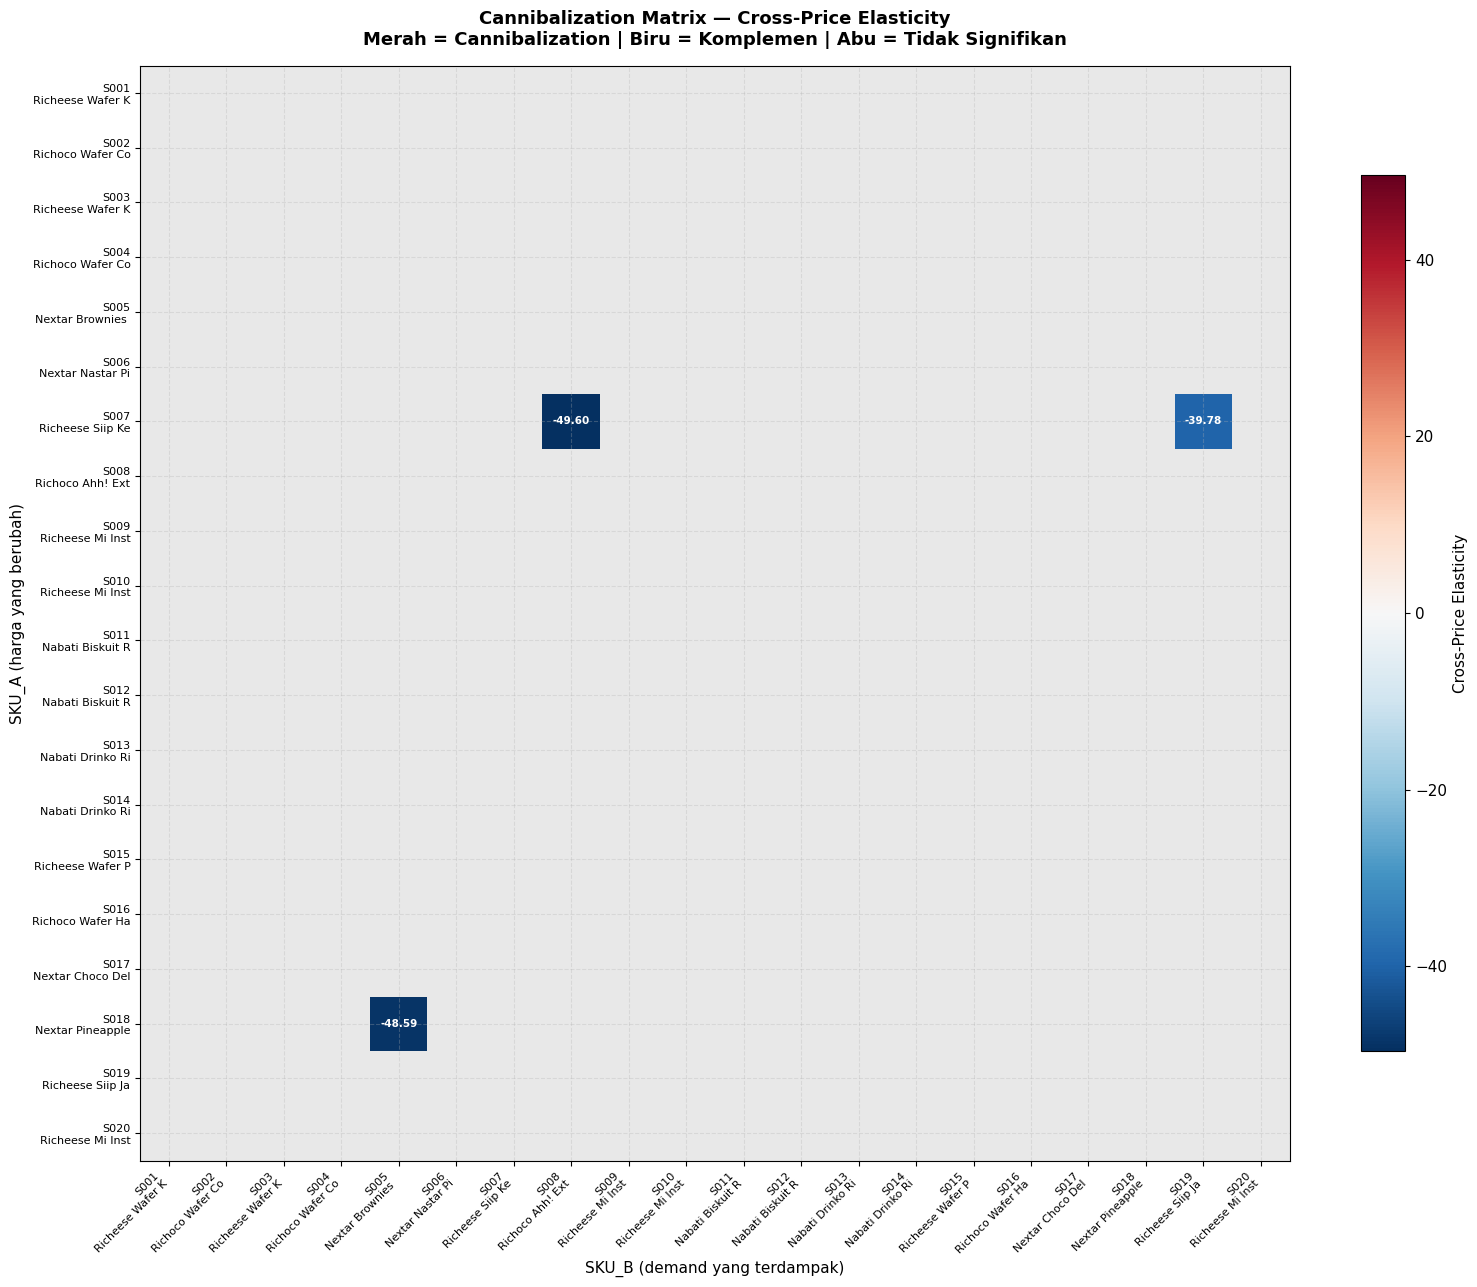

✓ Saved: phase2_cannibalization_matrix.png


In [28]:
# Step 5 — Cannibalization matrix heatmap

import matplotlib.pyplot as plt
import numpy as np

all_skus = sorted(elast_df["SKU_A"].unique())
matrix   = pd.DataFrame(np.nan, index=all_skus, columns=all_skus)

for _, row in elast_df.iterrows():
    if row["significant"]:
        matrix.loc[row["SKU_A"], row["SKU_B"]] = row["elasticity"]

sku_labels = {s: f"{s}\n{sku_name[s][:16]}" for s in all_skus}

fig, ax = plt.subplots(figsize=(16, 13))
cmap = plt.cm.RdBu_r
cmap.set_bad(color="#E8E8E8")

vals = matrix.values.astype(float)
finite_vals = vals[np.isfinite(vals)]
vmax = max(abs(finite_vals).max(), 0.5) if len(finite_vals) > 0 else 1.0

im = ax.imshow(vals, cmap=cmap, vmin=-vmax, vmax=vmax, aspect="auto")

ax.set_xticks(range(len(all_skus)))
ax.set_yticks(range(len(all_skus)))
ax.set_xticklabels([sku_labels[s] for s in all_skus], rotation=45, ha="right", fontsize=8)
ax.set_yticklabels([sku_labels[s] for s in all_skus], fontsize=8)

for i, sku_a in enumerate(all_skus):
    for j, sku_b in enumerate(all_skus):
        val = matrix.loc[sku_a, sku_b]
        if not np.isnan(val):
            color = "white" if abs(val) > vmax * 0.6 else "black"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    fontsize=7.5, color=color, fontweight="bold")

ax.set_xlabel("SKU_B (demand yang terdampak)", fontsize=11)
ax.set_ylabel("SKU_A (harga yang berubah)", fontsize=11)
ax.set_title(
    "Cannibalization Matrix — Cross-Price Elasticity\n"
    "Merah = Cannibalization | Biru = Komplemen | Abu = Tidak Signifikan",
    fontsize=13, fontweight="bold", pad=15
)
plt.colorbar(im, ax=ax, label="Cross-Price Elasticity", shrink=0.8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR_1 + "phase2_cannibalization_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved: phase2_cannibalization_matrix.png")

In [30]:
# debug — cek hasil regresi sebelum verdict
print("Total pasangan:", len(elast_df))
print("\nDistribusi verdict:")
print(elast_df["verdict"].value_counts())

print("\nSample 10 hasil regresi (sorted by p_value):")
display(elast_df.sort_values("p_value").head(10)[
    ["Category", "SKU_A_name", "SKU_B_name", "elasticity", "p_value", "verdict"]
])

Total pasangan: 58

Distribusi verdict:
verdict
Tidak Signifikan    53
Komplemen            5
Name: count, dtype: int64

Sample 10 hasil regresi (sorted by p_value):


,Category,SKU_A_name,SKU_B_name,elasticity,p_value,verdict
2,Extruded Snack,Richeese Siip Keju 20g,Richoco Ahh! Extruded 15g,-49.601,0.0087,Komplemen
3,Extruded Snack,Richeese Siip Keju 20g,Richeese Siip Jagung Bakar 20g,-39.782,0.0170,Komplemen
17,Kue/Pie,Nextar Pineapple Pie 30g,Nextar Brownies Pie 40g,-48.589,0.0374,Komplemen
19,Kue/Pie,Nextar Pineapple Pie 30g,Nextar Choco Delight 40g,-38.551,0.0515,Komplemen
8,Kue/Pie,Nextar Brownies Pie 40g,Nextar Nastar Pie 30g,-20.042,0.0991,Komplemen
28,Wafer,Richeese Wafer Keju 50g,Richoco Wafer Cokelat 50g,27.632,0.1115,Tidak Signifikan
33,Wafer,Richoco Wafer Cokelat 50g,Richeese Wafer Keju 50g,-26.683,0.1286,Tidak Signifikan
18,Kue/Pie,Nextar Pineapple Pie 30g,Nextar Nastar Pie 30g,-35.550,0.1619,Tidak Signifikan
4,Extruded Snack,Richoco Ahh! Extruded 15g,Richeese Siip Keju 20g,25.015,0.1698,Tidak Signifikan
52,Wafer,Richeese Wafer Pink Lava 50g,Richoco Wafer Hazelnut 50g,25.787,0.1705,Tidak Signifikan


In [31]:
# cek seberapa besar variasi harga per SKU per minggu
price_var = (
    weekly.groupby("SKU_ID")["effective_price"]
    .agg(["mean", "std", "min", "max"])
    .round(2)
)
price_var["cv"] = (price_var["std"] / price_var["mean"] * 100).round(2)  # coefficient of variation
price_var = price_var.sort_values("cv", ascending=False)
print("Variasi harga per SKU (cv = std/mean %):")
display(price_var)

Variasi harga per SKU (cv = std/mean %):


,mean,std,min,max,cv
SKU_ID,,,,,
S006,7200.48,477.44,6586.42,7616.40,6.63
S005,7203.92,474.91,6612.31,7625.85,6.59
S001,5441.48,288.53,5186.38,5797.85,5.30
S002,5448.48,281.38,5189.09,5820.29,5.16
S013,2779.57,16.24,2739.56,2811.01,0.58
S009,3316.32,11.52,3280.12,3334.16,0.35
S014,3792.77,11.87,3769.91,3811.75,0.31
S003,9476.78,29.16,9424.89,9530.33,0.31
S004,9473.16,27.86,9406.91,9518.96,0.29
